# **Repositorios de Datos**



1.   [Kaggle](https://www.kaggle.com/datasets)
2.   [UC Irvine Machine Learning Repository](https://archive.ics.uci.edu/)  
3.   [Our World in Data](https://ourworldindata.org/)




##**Recordando CL en PCA**


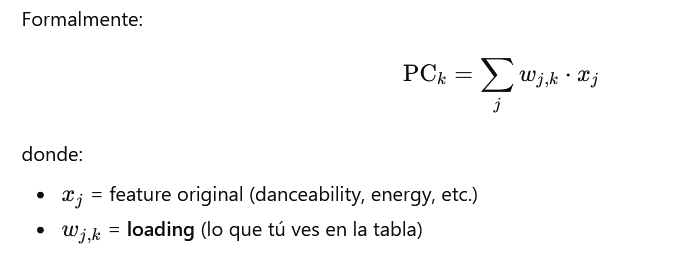

**Ejemplo 1: Spotify**

Varianza explicada por cada componente: [0.26519943 0.18702563]


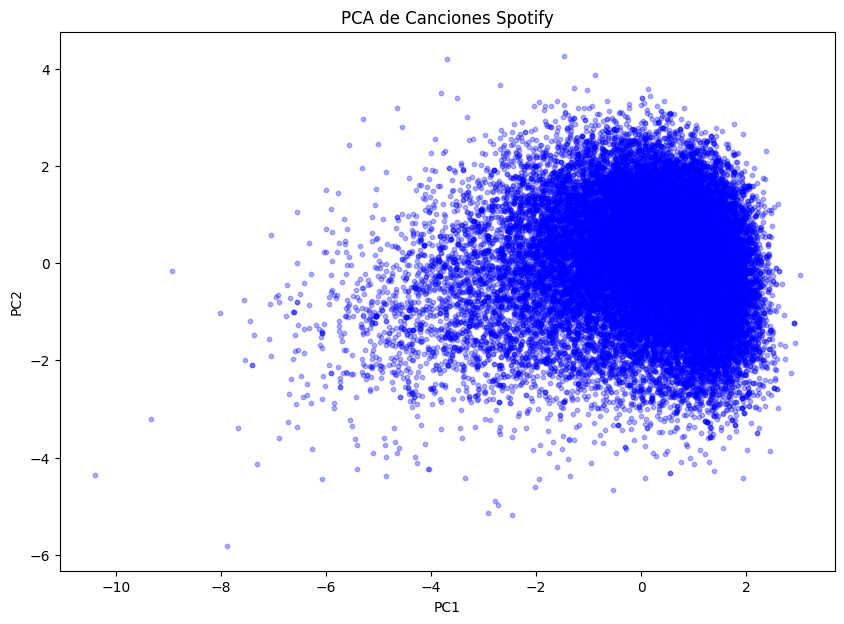

Contribución de variables a cada componente:
                       PC1       PC2
danceability     -0.019105  0.616976
energy            0.619209 -0.046654
valence           0.118010  0.570086
tempo             0.178738 -0.258529
loudness          0.563190  0.045518
speechiness      -0.007187  0.349120
acousticness     -0.498650  0.049165
instrumentalness -0.066753 -0.314570


In [1]:
# @title
import pandas as pd   #manejar el dataset como DataFrame.
from sklearn.preprocessing import StandardScaler  #normalizar variables (media=0, varianza=1).
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt  #graficar resultados.
# 0. Como usar PCA explicación por sklearn : https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html


# 1. Descargar dataset desde GitHub (TidyTuesday Spotify Songs)
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-01-21/spotify_songs.csv"
df = pd.read_csv(url)

# 2. Seleccionar variables numéricas relevantes
features = ["danceability", "energy", "valence", "tempo",
            "loudness", "speechiness", "acousticness", "instrumentalness"]
# Información de features en el dataset
#danceability: qué tan bailable es (0–1).
#energy: intensidad y actividad percibida (0–1).
#valence: positividad emocional de la canción (0–1).
# tempo: velocidad (beats por minuto, BPM).
# loudness: volumen medio en decibelios.
# speechiness: presencia de palabras habladas (rap, spoken word → valores altos) (0–1).
# acousticness: probabilidad de que sea acústica.
# instrumentalness: probabilidad de que no tenga voces.

# Construir el Dataframe (tabla de datos en 2D)
X = df[features].dropna()    # .dropna(): Elimina las filas que tienen valores faltantes (NaN)

# 3. Normalizar datos
scaler = StandardScaler()    #ver la descripcion de StandardScaler en https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html
X_scaled = scaler.fit_transform(X) #PCA necesita que las variables estén en la misma escala (media 0 y desviación estándar 1)

# 4. PCA
pca = PCA(n_components=2)   # puedo escoger el numero de componentes (e.g., PCA(n_components=2) o mantener cierta varianza retenida PCA(n_components=0.95) (float entre 0 y 1)
X_pca = pca.fit_transform(X_scaled)

print("Varianza explicada por cada componente:", pca.explained_variance_ratio_)

# 5. Graficar resultados
plt.figure(figsize=(10,7))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.3, s=10, c="blue")
#plt.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], alpha=0.3, s=10, c="blue")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA de Canciones Spotify")
plt.show()

# 6. Analizar contribuciones
loadings = pd.DataFrame(pca.components_.T, columns=["PC1", "PC2"], index=features)
#loadings = pd.DataFrame(pca.components_.T, columns=["PC1", "PC2", "PC3"], index=features)
print("Contribución de variables a cada componente:")
print(loadings)


**Discusión del Gráfico (Loadings)**

*   Eje X (PC1) izquierda = canciones menos enérgicas, derecha = canciones con alta energía.
*   Eje Y (PC2) parte baja del eje = canciones menos bailables, parte superior del eje = canciones más bailables y alegres.

La nube se ve concentrada en la zona derecha/arriba: la mayoría de canciones actuales tienden a ser relativamente energéticas, bailables y positivas.


**Ejemplo 2: Calidad De Aire**

Varianza explicada (PC1, PC2): [0.2754426  0.22671146]

Top variables por |PC1|:
                           PC1       PC2
total_sulfur_dioxide  0.487418  0.087266
free_sulfur_dioxide   0.430914  0.071933
volatile_acidity     -0.380757  0.117550
residual_sugar        0.345920  0.329914
sulphates            -0.294135  0.191716
chlorides            -0.290113  0.315258
fixed_acidity        -0.238799  0.336355
pH                   -0.218686 -0.155869
citric_acid           0.152388  0.183299
alcohol              -0.106437 -0.465058


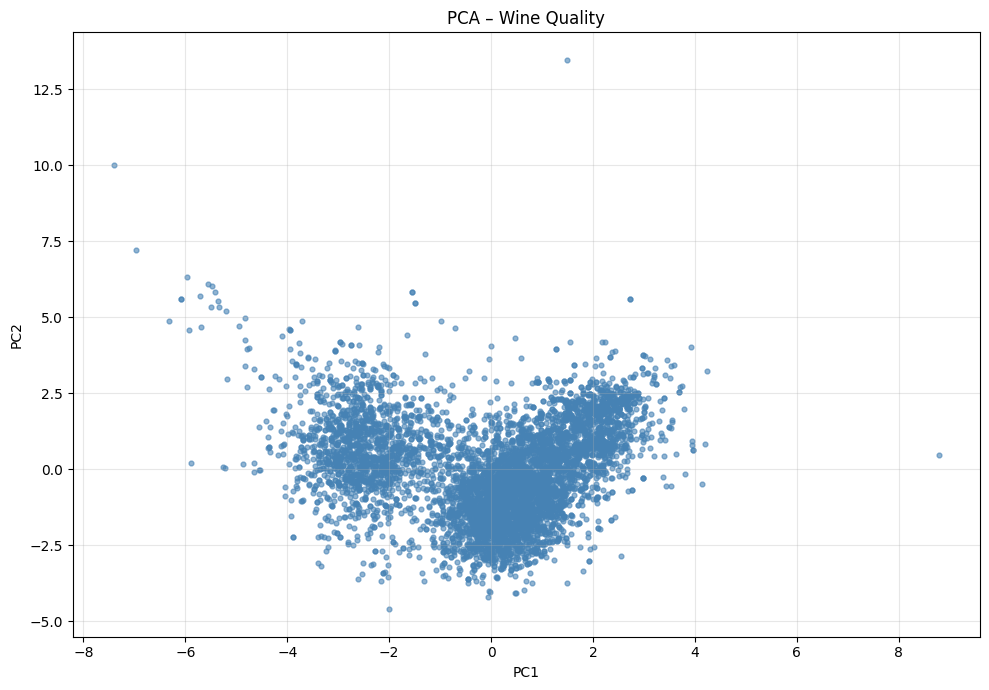

In [3]:
# @title
# Instalar
!pip install -q ucimlrepo
# Link: https://archive.ics.uci.edu/dataset/186/wine+quality
# PCA puro sobre features de Wine Quality (UCI id=186)
#Muestras: ~4900 vinos portugueses (tintos y blancos).
#Features (químicos): acidez fija, acidez volátil, ácido cítrico, azúcar residual, cloruros, dióxido de azufre libre y total, densidad, pH, sulfatos, alcohol.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from ucimlrepo import fetch_ucirepo

# 1) Cargar dataset
air_quality = fetch_ucirepo(id=186)
X = air_quality.data.features   # solo features

# 2) Preprocesar X
#  One-hot a categóricas (si las hay)
# Quitar inf/NaN
X_proc = pd.get_dummies(X, drop_first=True)
X_proc = X_proc.replace([np.inf, -np.inf], np.nan).dropna()  #Reemplaza -inf o inf con NaN y despues se los elemina con dropna

# 3) Estandarizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_proc)

# 4) PCA (2 componentes; usa 0.95 si quieres varianza retenida)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Varianza explicada (PC1, PC2):", pca.explained_variance_ratio_)

# 5) Loadings (qué variables definen cada PC)
loadings = pd.DataFrame(pca.components_.T,
                        index=X_proc.columns,
                        columns=["PC1","PC2"])
print("\nTop variables por |PC1|:")
print(loadings.reindex(loadings.PC1.abs().sort_values(ascending=False).index).head(10))

# 6) Gráfico sin usar y (PCA puro)
plt.figure(figsize=(10,7))
plt.scatter(X_pca[:,0], X_pca[:,1], s=12, alpha=0.6, color="steelblue")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA – Wine Quality")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()





*   PC1 (Positivo) separa vinos con más preservantes/azúcar de aquellos con más acidez y minerales. Normalmente los vinos blancos tienden a tener más sulfuroso añadido para conservación y más azúcar (dulces o semidulces).
*   PC1 (Negativo) se asocia más a acidez, es decir este cluster se asocia más con vinos tintos, que suelen ser más ácidos, menos dulces y menos dependientes de dióxido de azufre como preservante.
*   PC2 (negativo) Vinos en la parte baja del gráfico serían los de mayor graduación alcohólica.
*   PC2(positivo) serían los con más azúcar residual y cloruros.



Un signo positivo significa que a medida que la variable crece, también crece el valor del componente. Ejm: Si un vino tiene mucho azufre (0.48) pero poca acidez volátil (-0.38), tendrá un valor alto en PC1.

Un signo negativo significa que a medida que la variable crece, el valor del componente disminuye. Ejm: Si un vino tiene alta acidez volátil y poco azufre, caerá en el lado negativo de PC1.

**Entendiendo One hot Encoding**

In [4]:
# @title
import pandas as pd

# Dataset de ejemplo
X = pd.DataFrame({
    "Color": ["Rojo", "Azul", "Verde", "Rojo", "Azul"],
    "Tamaño": ["S", "M", "L", "M", "S"],
    "Peso": [1.2, 2.5, 3.0, 2.0, 1.5]
})
print("Dataset original")
print(X)

# Aplicamos one hot encoding
X_proc = pd.get_dummies(X, drop_first=True, dtype=int)

print("\nDataset transformado")
print(X_proc)

# Color_Rojo  Color_Verde
# 0           0   ← Azul (categoría de referencia)
# 1           0   ← Rojo
# 0           1   ← Verde


Dataset original
   Color Tamaño  Peso
0   Rojo      S   1.2
1   Azul      M   2.5
2  Verde      L   3.0
3   Rojo      M   2.0
4   Azul      S   1.5

Dataset transformado
   Peso  Color_Rojo  Color_Verde  Tamaño_M  Tamaño_S
0   1.2           1            0         0         1
1   2.5           0            0         1         0
2   3.0           0            1         0         0
3   2.0           1            0         1         0
4   1.5           0            0         0         1
